# 자동차 보험 상품 출시의 임계 경로 일정 관리

## 요약

개인용 자동차 보험 상품을 출시하는 일은 여러 부서가 함께하는 프로그램입니다. 계리사는 리스크에 가격을 매기고, 컴플라이언스 부서는 주(state)에 요율을 신고하고 승인을 기다리며, IT는 보험 관리 시스템을 구성하고, 영업 부서는 대리점을 교육합니다. 이 작업들은 엄격한 선후행 관계를 가지므로, 출시일은 계획 전체를 관통하는 가장 긴 종속 사슬 -- **임계 경로(critical path)** -- 에 의해 결정됩니다.

이 노트북은 11개 출시 작업으로 구성된 활동-노드(Activity-on-Node) 프로젝트 네트워크를 구축하고 **PROC OPTMODEL**로 완전한 **임계 경로법(Critical Path Method, CPM)** 일정을 계산합니다. CPM의 전진 계산과 후진 계산은 선후행 그래프 위에서 푸는 선형 계획법입니다. 전진 계산(시작점으로부터의 최장 경로)은 각 작업의 가장 이른 시작과 종료를 제공하고, 후진 최장 경로 계산은 가장 늦은 시작과 종료, 그리고 **총 여유(total float, 일정 여유분)**를 제공합니다. 아래 결과는 전적으로 이 노트북의 코드로 생성됩니다 -- 서술에 나오는 모든 수치는 실행된 출력에서 다시 읽어온 값입니다.

**일정이 보여주는 것.** 01JUN2026을 기준으로 한 주 5일 근무 달력에서 프로그램은 **97 근무일**에 걸쳐 있으며 **13OCT2026**에 끝납니다. 11개 작업 중 9개가 임계 경로 위에 있고(킥오프 → 시장조사 → 손실데이터취합 → 가격산정 → 시스템설계 → 시스템구축 → UAT → 대리점교육 → 출시) 여유가 0입니다. 오직 규제 분기 -- **요율 신고(rate filing)**와 **승인(approval)** -- 만 여유를 가집니다. 병렬로 진행되는 시스템 구축 분기가 수렴하는 두 경로 중 더 긴 쪽이기 때문에, 각 작업은 출시를 미루지 않고 최대 **30 근무일**까지 지연될 수 있습니다.

## 구축 방법

CPM은 전통적으로 SAS/OR 프로시저이지만, 그 핵심 계산은 선후행 그래프 위에서 푸는 두 개의 최장 경로 문제이며, PROC OPTMODEL은 이를 작은 선형 계획법으로 직접 표현합니다.

- **전진 계산(가장 이른 시각).** 모든 선후행 아크에 대해 `ES[successor] >= ES[predecessor] + duration + lag` 제약 아래에서 가장 이른 시작 변수를 최소화합니다. 최적해에서 각 `ES`는 프로젝트 시작점으로부터의 최장 경로, 즉 해당 작업이 시작될 수 있는 가장 이른 시각과 같아집니다.
- **후진 계산(가장 늦은 시각 / 여유).** 각 작업에 대해 프로젝트 종료까지 남은 최장 경로(`TAIL`)를 계산합니다. 가장 늦은 시작은 `makespan - TAIL`이고, **총 여유**는 `late start - early start`입니다. 여유가 0인 작업이 임계 작업입니다.

네트워크, 소요 기간, 선후행 지연(lag), 작업별 자원 수요는 모두 코드 안에서 생성되며 외부 입력이 없습니다. 근무일 기준 달력 날짜는 `INTNX('weekday', ...)`로 산출하여 주말은 건너뜁니다.

## 데이터

| 데이터셋 | 행 수 | 주요 변수 | 설명 |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | 활동 마스터: 각 출시 작업, 근무일 기준 소요 기간, 그리고 매일 필요한 계리사 / 개발자 인원 |
| `arcs`  | 12 | `pred`, `succ`, `lag` | 활동-노드 네트워크의 선후행 아크. `lag`는 근무일 단위의 종료-시작(finish-to-start) 지연이다(승인 후 규제 대기 기간). |

네트워크의 키는 숫자형 활동 ID로 잡아 선후행 그래프가 OPTMODEL의 튜플 집합으로 깔끔하게 읽히도록 하며, 읽기 좋은 `activity` 이름은 이후 일정에 다시 병합합니다.

In [1]:
데이터 acts;
   길이 activity $30;
   입력 id activity $ dur actuary developer;
   자료;
1 킥오프 3 1 0
2 시장조사 8 2 0
3 손실데이터취합 10 3 0
4 가격산정 9 3 1
5 요율신고 4 1 0
6 승인 6 1 0
7 시스템설계 12 1 2
8 시스템구축 18 0 3
9 UAT 15 0 2
10 대리점교육 20 1 1
11 출시 2 1 1
;
실행;

데이터 arcs;
   입력 pred succ lag;
   자료;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
실행;

/* OPTMODEL을 위한 소요 기간 숫자 전용 뷰 */
데이터 acts_n; 설정 acts; 유지 id dur; 실행;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 전진 계산 -- 가장 이른 시작과 종료

전진 계산은 최장 경로 LP입니다. 모든 아크에 대한 제약 `ES[j] >= ES[i] + dur[i] + lag[i,j]`는 각 작업이 모든 선행 작업이 끝나기 전에는(그리고 규제 지연이 있으면 그만큼 더) 시작하지 못하도록 강제하며, 가장 이른 시작 변수를 최소화하면 각 작업이 가장 긴 선행 경로 값으로 밀려납니다. 풀린 `ES` 값을 OPTMODEL 변수에서 곧바로 `fwd`에 씁니다.

In [2]:
처리 optmodel;
   설정 NODES; num dur{NODES};
   READ 데이터 acts_n INTO NODES=[id] dur=dur;

   설정 <num,num> ARCS; num lag{ARCS};
   READ 데이터 arcs INTO ARCS=[pred succ] lag=lag;

   변수 ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREATE 데이터 fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 후진 계산 -- 가장 늦은 시각과 총 여유

`TAIL[a]`는 작업 `a`에서 프로젝트 종료까지의 최장 경로이므로, 작업 자신의 소요 기간과 각 후행 작업에 대한 지연 및 그 후행 작업의 tail을 모두 포함해야 합니다: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. tail을 최소화하면 가장 팽팽한 값이 나옵니다. 프로젝트 **makespan**은 가장 큰 이른 종료 값이며, 각 작업의 **가장 늦은 시작**은 `makespan - TAIL`, **총 여유**는 `late start - early start`입니다. 여유가 0이면 임계 경로에 있음을 뜻합니다.

In [3]:
처리 optmodel;
   설정 NODES; num dur{NODES};
   READ 데이터 acts_n INTO NODES=[id] dur=dur;

   설정 <num,num> ARCS; num lag{ARCS};
   READ 데이터 arcs INTO ARCS=[pred succ] lag=lag;

   변수 TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREATE 데이터 bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 일정과 달력 조립

가장 이른 시작과 tail을 활동 마스터에 다시 병합하고, 가장 늦은 시작 / 종료와 총 여유를 도출한 뒤, 근무일 오프셋을 `INTNX('weekday', ...)`로 달력 날짜에 매핑하여 날짜가 영업일에 떨어지도록 합니다. 총 여유가 0인 작업은 **임계(critical)**로 표시됩니다.

In [4]:
%LET anchor = '01jun2026'd;

데이터 sched0;
   결합 acts fwd bwd; 기준 id;
   ef = es + dur;            /* 가장 이른 종료 */
실행;

처리 평균 데이터=sched0 NOPRINT;
   출력 out=mk(제거=_type_ _freq_) MAX(ef)=makespan;
실행;

데이터 sched;
   만약 _n_=1 이면 설정 mk;
   설정 sched0;
   보존 mspan;
   만약 _n_=1 이면 mspan = makespan;
   ls = mspan - tail;        /* 가장 늦은 시작 */
   lf = ls + dur;            /* 가장 늦은 종료 */
   tfloat = ls - es;         /* 총 여유       */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   길이 cclass $12;
   만약 critical 이면 cclass='임계';
   아니면 cclass='여유';
   형식 e_start e_finish l_start l_finish date9.;
실행;

처리 정렬 데이터=sched out=sched_es; 기준 es id; 실행;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## CPM 일정

이른/늦은 시작과 종료는 01JUN2026 기준점(0일차)으로부터의 근무일 수입니다. **임계** 등급의 작업은 총 여유가 0입니다.

In [5]:
제목 'CPM 일정 -- 근무일 기준 시각과 총 여유';
처리 인쇄 데이터=sched_es noobs 라벨;
   변수 activity dur es ef ls lf tfloat cclass;
   라벨 activity='작업' dur='소요일수(근무일)' es='이른 시작(ES)' ef='이른 종료(EF)'
         ls='늦은 시작(LS)' lf='늦은 종료(LF)' tfloat='총 여유' cclass='등급';
실행;

                                               CPM 일정 -- 근무일 기준 시각과 총 여유                                                


                   작업                소요일수(근무일)          이른 시작(ES)          이른 종료(EF)          늦은 시작(LS)          늦은 종료(LF)        총 여유      등급
---------------------  -----------------------  -----------------  -----------------  -----------------  -----------------  ----------  ------
킥오프                                          3                  0                  3                  0                  3           0  임계
시장조사                                         8                  3                 11                  3                 11           0  임계
손실데이터취합                                     10                 11                 21                 11                 21           0  임계
가격산정                                         9                 21                 30                 21                 30           0  임계
요율신고                               


NOTE: Option TITLE changed to CPM 일정 -- 근무일 기준 시각과 총 여유.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


이른 시작 열은 종속 사슬을 따라갑니다. 킥오프는 0일차에 시작하고, 이후의 각 작업은 선행 작업이 끝나는 시점에 시작합니다. 프로젝트는 가장 큰 이른 종료 시점에 완료됩니다.

## 임계 경로

여유가 0인 작업만 달력 날짜와 함께 나열하면 출시일을 결정하는 사슬이 드러납니다. 이 작업들에서 지연이 생기면 출시일도 그만큼 뒤로 밀립니다.

In [6]:
제목 '임계 경로 (총 여유 = 0)와 달력 날짜';
처리 인쇄 데이터=sched_es noobs 라벨;
   조건 critical=1;
   변수 activity dur e_start e_finish;
   라벨 activity='작업' dur='소요일수(근무일)'
         e_start='이른 시작일' e_finish='이른 종료일';
실행;

데이터 mkrep;
   설정 mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   형식 anchor FINISH date9.;
실행;
제목 '프로젝트 기간';
처리 인쇄 데이터=mkrep noobs 라벨;
   변수 anchor makespan FINISH;
   라벨 anchor='기준일(0일차)'
         makespan='총 기간(근무일)'
         FINISH='예상 완료일';
실행;

                                                임계 경로 (총 여유 = 0)와 달력 날짜                                                 


                   작업                소요일수(근무일)            이른 시작일            이른 종료일
---------------------  -----------------------  ----------------  ----------------
킥오프                                          3         01JUN2026         03JUN2026
시장조사                                         8         04JUN2026         15JUN2026
손실데이터취합                                     10         16JUN2026         29JUN2026
가격산정                                         9         30JUN2026         10JUL2026
시스템설계                                       12         13JUL2026         28JUL2026
시스템구축                                       18         29JUL2026         21AUG2026
UAT                                         15         24AUG2026         11SEP2026
대리점교육                                       20         14SEP2026         09OCT2026
출시                                           2 


NOTE: Option TITLE changed to 임계 경로 (총 여유 = 0)와 달력 날짜.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 프로젝트 기간.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 여유가 있는 곳

임계 경로가 아닌 작업들은 규제 분기입니다. 이들의 가장 늦은 시작 / 종료는 각 작업이 출시를 밀기 시작하기 전까지 얼마나 움직일 수 있는지를 보여 줍니다. 여기서는 자유 여유(free float)가 총 여유와 같은데, 이 작업들은 대리점 교육에서 다시 합류하기 전까지 다른 어떤 작업도 이들에 의존하지 않기 때문입니다.

In [7]:
제목 '비임계 작업과 일정 여유';
처리 인쇄 데이터=sched_es noobs 라벨;
   조건 critical=0;
   변수 activity dur e_start e_finish l_start l_finish tfloat;
   라벨 activity='작업' dur='소요일수(근무일)'
         e_start='이른 시작일' e_finish='이른 종료일'
         l_start='늦은 시작일' l_finish='늦은 종료일'
         tfloat='총 여유';
실행;

                                                     비임계 작업과 일정 여유                                                      


          작업                소요일수(근무일)            이른 시작일            이른 종료일            늦은 시작일            늦은 종료일        총 여유
------------  -----------------------  ----------------  ----------------  ----------------  ----------------  ----------
요율신고                                4         13JUL2026         16JUL2026         24AUG2026         27AUG2026          30
승인                                  6         17JUL2026         24JUL2026         28AUG2026         04SEP2026          30




NOTE: Option TITLE changed to 비임계 작업과 일정 여유.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## 일정 폭포수(waterfall)

작업마다 이른 시작에서 이른 종료까지를 프로젝트 순서대로 그린 고저(high-low) 막대는 계획의 간트(Gantt) 스타일 폭포수를 만들어 줍니다. 각 막대의 높이는 작업 소요 기간이며, 계단은 97 근무일의 makespan까지 올라갑니다. 상승하는 대각선 *아래에* 놓인 작업 -- 어떤 막대의 위쪽 끝이 다음 막대의 아래쪽 끝보다 낮은 경우 -- 이 여유를 가진 작업입니다.

                                                자동차보험 상품 출시 -- 이른 일정 폭포수                                                




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to 자동차보험 상품 출시 -- 이른 일정 폭포수.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


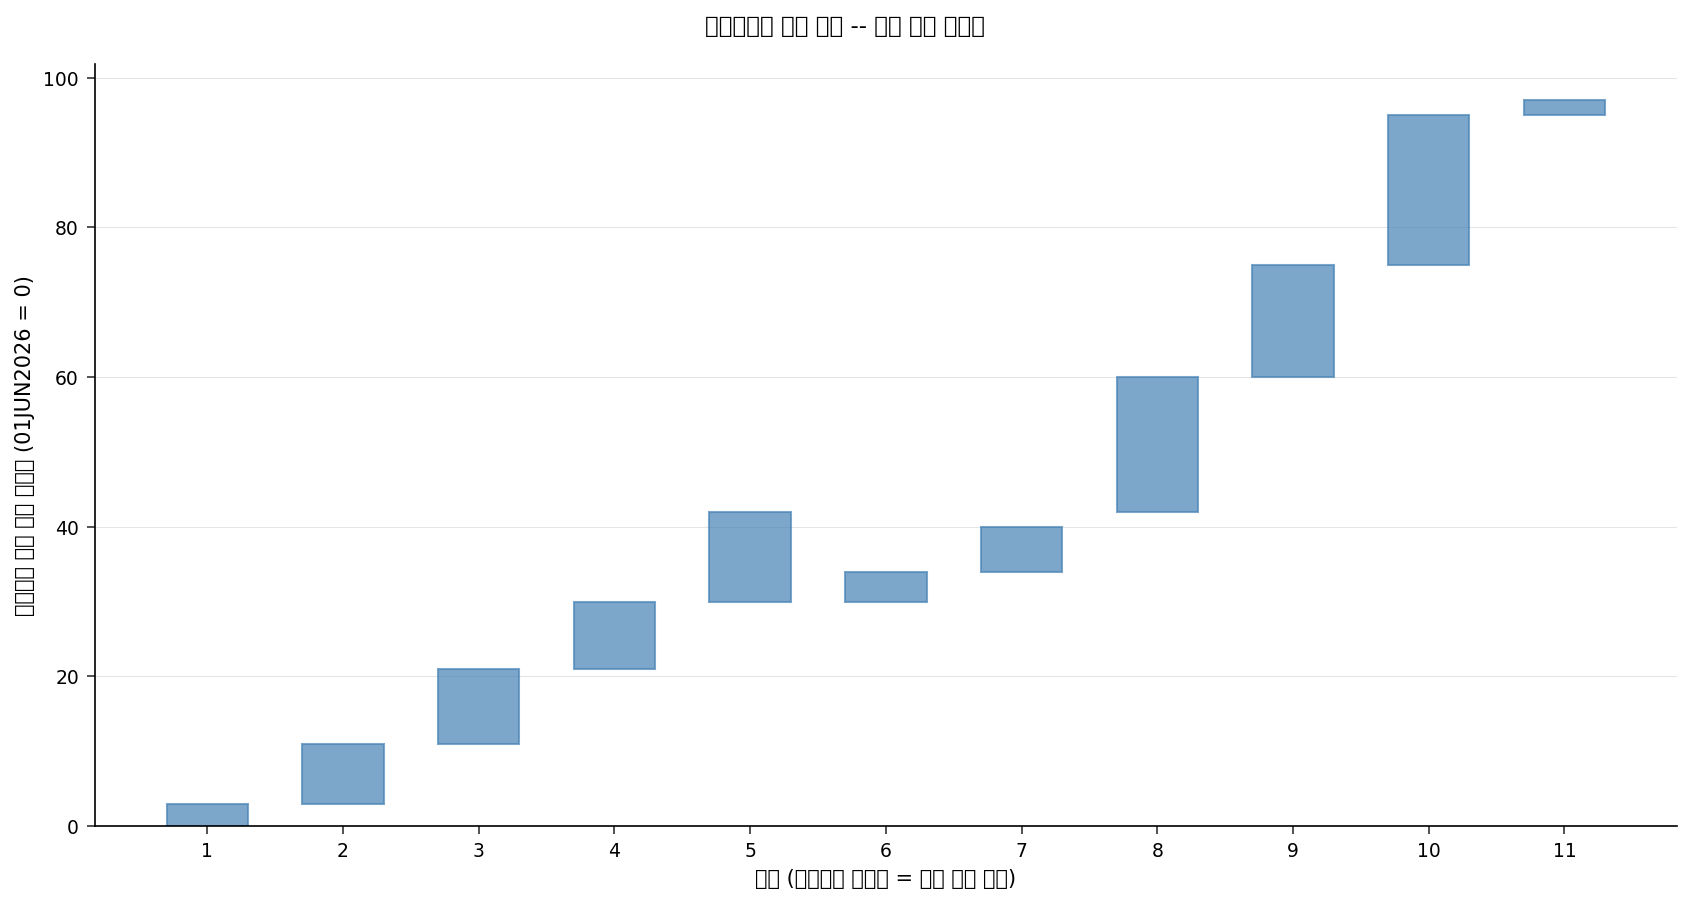

In [8]:
데이터 gantt; 설정 sched_es;
   ord = es;          /* 숫자 x = 이른 시작 순서 */
실행;
처리 정렬 데이터=gantt; 기준 ord activity; 실행;
데이터 gantt; 설정 gantt; ax = _n_; 실행;   /* 1..11 압축 x 인덱스 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
제목 '자동차보험 상품 출시 -- 이른 일정 폭포수';
처리 SGPLOT 데이터=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS 라벨='작업 (왼쪽에서 오른쪽 = 이른 시작 순서)'
         integer VALUES=(1 까지 11 기준 1);
   YAXIS 라벨='프로젝트 시작 기준 근무일 (01JUN2026 = 0)' grid;
실행;
ODS GRAPHICS OFF;

왼쪽에서 오른쪽으로 읽으면 막대가 임계 사슬을 따라 연속적으로 올라갑니다. 계단을 끊는 두 작업 -- 앞선 막대의 위쪽 끝보다 낮게 시작하는 -- 은 요율 신고(rate filing)와 승인(approval)으로, 여유를 가진 활동입니다.

## 작업별 총 여유

각 작업의 총 여유를 그리면 임계 경로가 분명하게 드러납니다. 모든 임계 작업은 0에 놓이고, 오직 두 개의 규제 작업만 그 위로 올라갑니다.

                                                 작업별 총 여유 (0 = 임계 경로 위)                                                 




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to 작업별 총 여유 (0 = 임계 경로 위).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


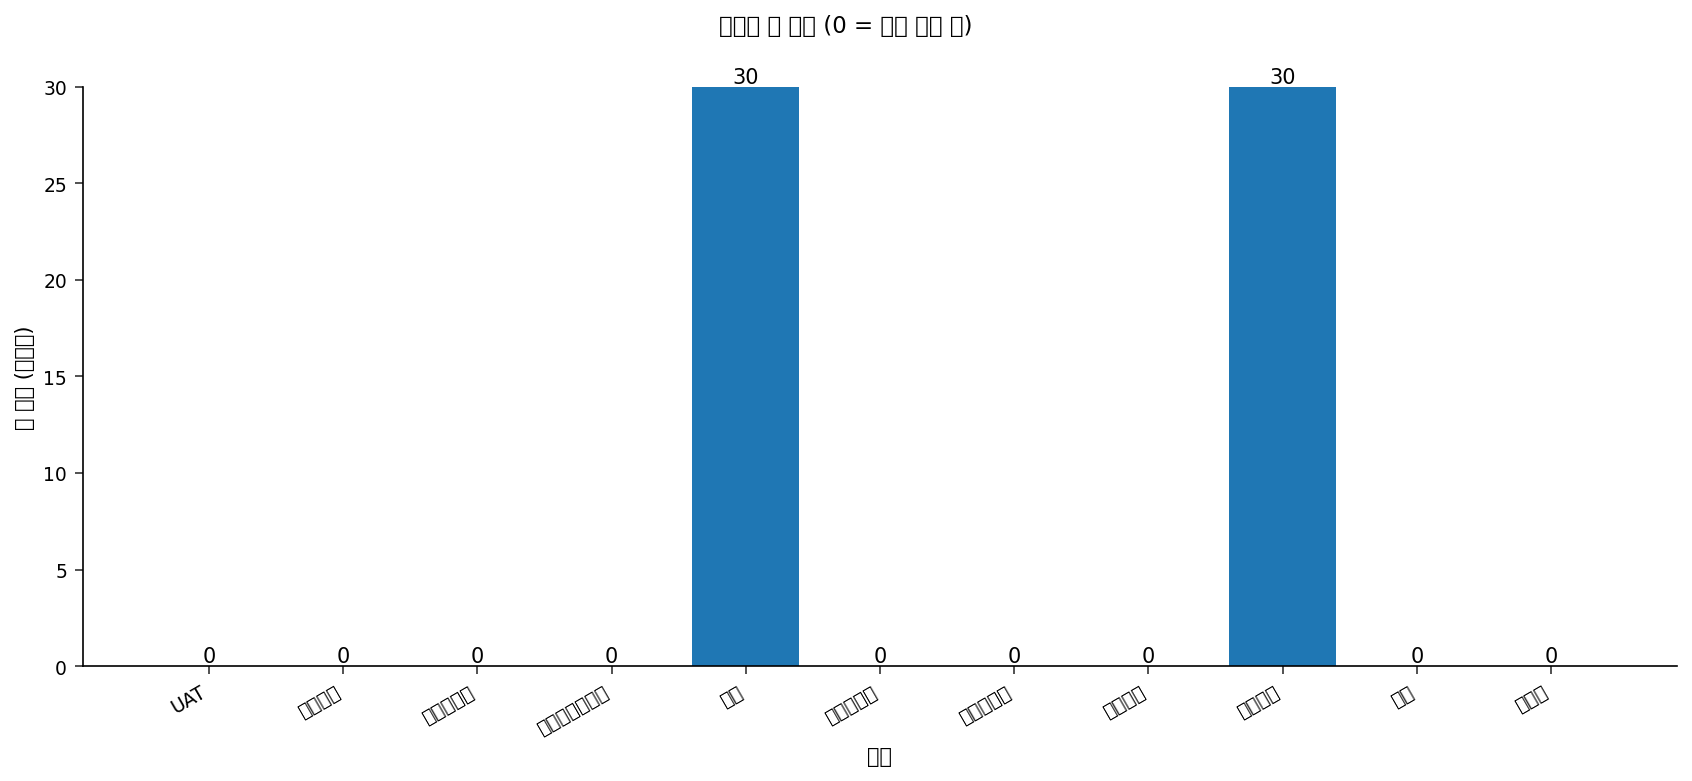

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
제목 '작업별 총 여유 (0 = 임계 경로 위)';
처리 SGPLOT 데이터=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS 라벨='작업' fitpolicy=rotatethin;
   YAXIS 라벨='총 여유 (근무일)';
실행;
ODS GRAPHICS OFF;

## 이른 일정 하의 자원 부하

타이밍을 넘어, 이 계획은 두 개의 전문 인력 풀을 두고 경합합니다. 각 작업을 그것이 차지하는 근무일에 걸쳐 펼치고 일별 수요를 합하면 자원 부하 프로파일 -- 모든 작업이 가능한 한 이른 시각에 시작한다고 할 때 계획이 매일 필요로 하는 계리사와 개발자 수 -- 이 나옵니다. 그 정점은 프로그램이 한 번에 요구하는 최대 용량입니다.

                                                  이른 일정 하의 일별 최대 자원 부하                                                  

                                                  The MEANS Procedure

 Variable    Label         Maximum
 ---------------------------------
 ACTUARIES   계리사                 3
 DEVELOPERS  개발자                 3
 ---------------------------------

                                                 이른 일정 하의 일별 계리사·개발자 부하                                                 




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to 이른 일정 하의 일별 최대 자원 부하.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to 이른 일정 하의 일별 계리사·개발자 부하.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


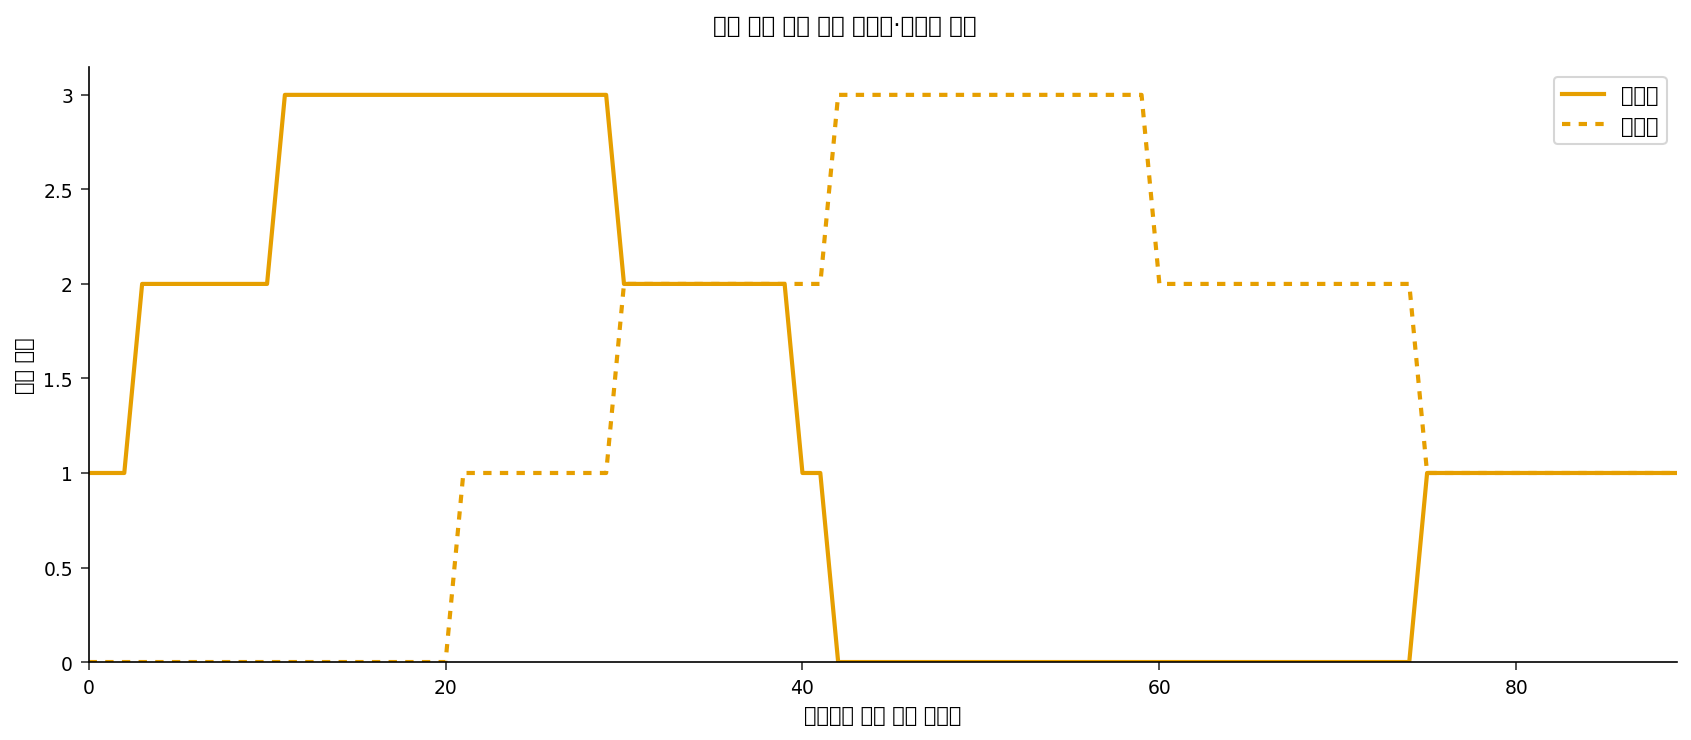

In [10]:
데이터 LOAD;
   설정 sched;
   반복 d = es 까지 ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      출력;
   종료;
   유지 day a_use d_use;
실행;

처리 평균 데이터=LOAD NOPRINT NWAY;
   분류 day;
   변수 a_use d_use;
   출력 out=rprofile(제거=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
실행;
처리 정렬 데이터=rprofile; 기준 day; 실행;

제목 '이른 일정 하의 일별 최대 자원 부하';
처리 평균 데이터=rprofile MAX maxdec=0;
   변수 actuaries developers;
   라벨 actuaries='계리사' developers='개발자';
실행;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
제목 '이른 일정 하의 일별 계리사·개발자 부하';
처리 SGPLOT 데이터=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='계리사';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='개발자';
   XAXIS 라벨='프로젝트 시작 기준 근무일';
   YAXIS 라벨='필요 인원' MIN=0;
   keylegend / location=inside position=topright;
실행;
ODS GRAPHICS OFF;

## 결과 해석

- **출시일은 규제 트랙이 아니라 구축 트랙이 결정한다.** 임계 경로는 킥오프 → 시장조사 → 손실데이터취합 → 가격산정 → 시스템설계 → 시스템구축 → UAT → 대리점교육 → 출시로 이어지며 makespan은 97 근무일입니다(13OCT2026 종료). 이 작업들은 모두 여유가 0이므로, 어느 하나라도 지연되면 출시가 그만큼 밀립니다.

- **규제 분기에는 한 달의 여유가 있다.** 요율 신고와 승인은 각각 30 근무일의 총 여유를 가집니다. 가격 산정이 끝난 뒤 이들은 가장 늦은 시작 날짜까지 늦춰 시작해도 제때 대리점 교육에 다시 합류할 수 있는데, 병렬 시스템 구축 분기(시스템설계 → 시스템구축 → UAT)가 출시로 이어지는 두 경로 중 더 길기 때문입니다. 계획 관점에서 여기서 구속 제약은 신고가 *아니라* 보험 시스템 구축입니다.

- **전문 인력 수요는 국면마다 다르게 정점을 찍는다.** 부하 프로파일을 보면 계리사 수요는 이른 시기(가격 산정까지)에, 개발자 수요는 이후(시스템 구축까지)에 정점을 찍으며, 각각 하루 3명에서 최고에 이릅니다. 두 정점이 서로 다른 국면에 떨어지므로, 작고 순차적인 전문 인력 팀으로도 계획을 감당할 수 있습니다 -- 프로그램은 최대 계리사 인원과 개발자 인원을 동시에 필요로 하지 않습니다.

**비즈니스 시사점.** CPM은 출시 작업 목록을 실행 가능한 일정으로 바꿔 줍니다. 보험사가 13OCT2026을 맞추기 위해 반드시 지켜야 할 구축 트랙 활동을 식별하고, 규제 신고에 쓸 수 있는 한 달의 여유를 정량화하며, 엇갈린 계리사·개발자 정점 덕분에 군살 없는 전문 인력 팀으로도 계획을 수행할 수 있음을 보여 줍니다.

*구현 참고:* SAS는 이를 PROC CPM(SAS/OR)으로 계산합니다. Jenner는 이 방법의 바탕이 되는 두 최장 경로 선형 계획법을 PROC OPTMODEL로 풀어 동일한 전진/후진 임계 경로 결과에 도달합니다.